任务 1：det = 面积缩放率（可视化验证）

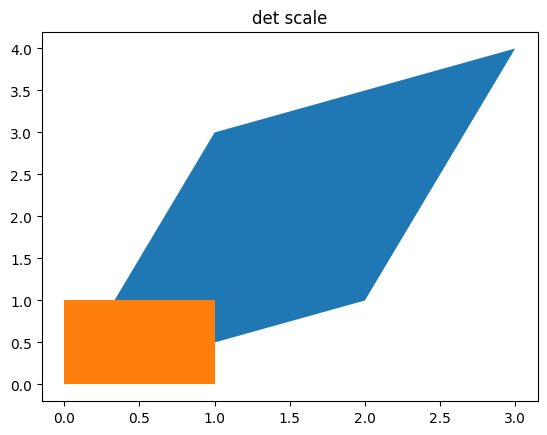

det:
 5.000000000000001


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def draw_square(M):
    rect_x = np.array(M[0,:])
    rect_y = np.array(M[1,:])
    plt.fill(rect_x,rect_y)

M = np.array([[2., 1.],[1., 3.]])

basic_points = np.array([[0,1,1,0,0],[0,0,1,1,0]])
transformed_points = M @ basic_points

draw_square(transformed_points)
draw_square(basic_points)
plt.title("det scale")
plt.show()

print("det:\n", np.linalg.det(M))

任务 2：det < 0 = 定向翻转

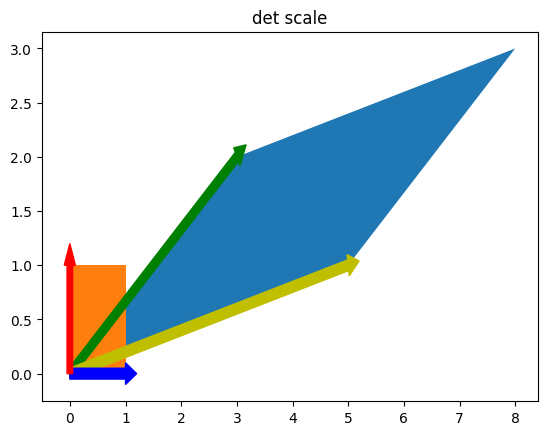

det:
 -6.999999999999999


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def draw_square(M):
    rect_x = np.array(M[0,:])
    rect_y = np.array(M[1,:])
    plt.fill(rect_x,rect_y)

M = np.array([[3., 5.],[2., 1.]])

basic_points = np.array([[0,1,1,0,0],[0,0,1,1,0]])
transformed_points = M @ basic_points

draw_square(transformed_points)
draw_square(basic_points)
plt.arrow(0,0,M[0,0],M[1,0], width=0.1, head_width=0.2,head_length=0.2,color='g')
plt.arrow(0,0,M[0,1],M[1,1], width=0.1, head_width=0.2,head_length=0.2,color='y')
plt.arrow(0,0,1,0, width=0.1, head_width=0.2,head_length=0.2,color='b')
plt.arrow(0,0,0,1, width=0.1, head_width=0.2,head_length=0.2,color='r')
plt.title("det scale")
plt.show()

print("det:\n", np.linalg.det(M))

总结任务一二：
 |det > 0 的时候|面积被单纯放大为 det(M) = 5 倍|
 |det < 0 的时候|面积不仅被缩放det(M) = -7 倍，基向量i-hat和j-hat也从逆时针转变为顺时针|

 注：蓝色和红色为原本基向量的i-hat和j-hat
     绿色和黄色为变换后的向量的i-hat和j-hat

补充结论：det 的绝对值 = 面积缩放率，det 的符号 = 定向（手性）是否翻转。面积本身永不为负，负号编码的是"翻转"这个动作，而不是"负面积"。

任务 3：det = 0 = 空间塌缩

det: 0.0
rank: 1


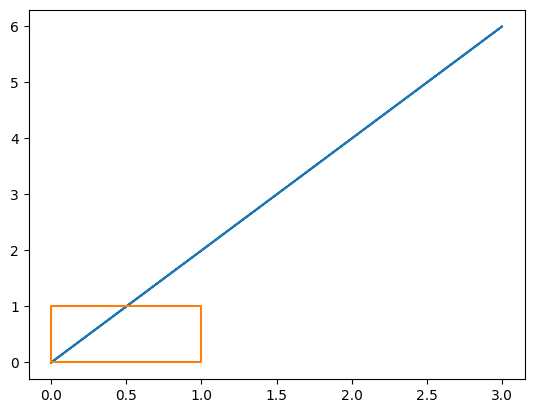

In [66]:
import numpy as np
import matplotlib.pyplot as plt

def draw_square(M):
    rect_x = np.array(M[0,:])
    rect_y = np.array(M[1,:])
    plt.plot(rect_x,rect_y)

M = np.array([[1.,2.],[2.,4.]])
print("det:",np.linalg.det(M))
print("rank:",np.linalg.matrix_rank(M))
basic_points = np.array([[0,1,1,0,0],[0,0,1,1,0]])

draw_square(M @basic_points)
draw_square(basic_points)
plt.show()



这次整个正方形被压缩到了一条**过原点**的直线上（y = 2x）。

关键辨析：`draw_square(M)` 和 `draw_square(M @ basic_points)` 画的是不同的东西——

- 前者连接 M 的两列（Mî 和 Mĵ 两个落点之间的线段），是"新原料"的特写。它过不过原点是巧合：两个落点恰好共线才躺在过原点的线上
- 后者是四个顶点变换后的连线，是"整个正方形的命运"。原点 (0,0) 变换后永远还在原点（线性变换的入场条件），所以塌缩像**必然过原点**

因果：基向量共线是**原因**（det=0，rank=1），全空间被吸到一条过原点的直线上是**效果**（列空间从二维塌成一维）。塌缩线 = 列空间 = 共线基向量的 span，而 span 必含原点（0·v = 0）。

任务 4：逆矩阵与解方程任务

正矩阵：
[[2 1]
 [1 3]]，
逆矩阵：
[[ 0.6 -0.2]
 [-0.2  0.4]]
正、逆矩阵相乘： [[ 1.00000000e+00  0.00000000e+00]
 [-5.55111512e-17  1.00000000e+00]]
正、逆矩阵相乘后求行列式： 1.0
[1. 3.]
[1. 3.]


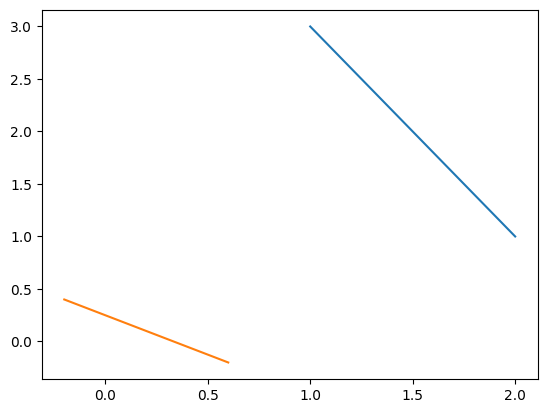

In [67]:
import numpy as np
import matplotlib.pyplot as plt

def draw_square(M):
    rect_x = np.array(M[0,:])
    rect_y = np.array(M[1,:])
    plt.plot(rect_x,rect_y)

A = np.array([[2,1],[1,3]])
A_inv = np.linalg.inv(A)
print("正矩阵：\n{}，\n逆矩阵：\n{}".format(A,A_inv))
print("正、逆矩阵相乘：",A @ A_inv)
print("正、逆矩阵相乘后求行列式：",np.linalg.det(A @ A_inv))

#必会报错，强调秩为1的矩阵无法求逆矩阵，因为被压缩的维度无法复原
#M = np.array([[1.,2.],[2.,4.]])
#problem = np.linalg.inv(M)
#---------------------------------------------------------------------------
#LinAlgError                               Traceback (most recent call last)
#Cell In[56], line 16
#     13 print("正、逆矩阵相乘后求行列式：",np.linalg.det(A @ A_T))
#     15 M = np.array([[1.,2.],[2.,4.]])
#---> 16 problem = np.linalg.inv(M)
#     17 print(problem)
#     19 x = A_T @ [5, 10]
#
#File /mnt/d/study-space/Ai/.venv/lib/python3.10/site-packages/numpy/linalg/_linalg.py:609, in inv(a)
#    606 signature = 'D->D' if isComplexType(t) else 'd->d'
#    607 with errstate(call=_raise_linalgerror_singular, invalid='call',
#    608               over='ignore', divide='ignore', under='ignore'):
#--> 609     ainv = _umath_linalg.inv(a, signature=signature)
#    610 return wrap(ainv.astype(result_t, copy=False))
#
#File /mnt/d/study-space/Ai/.venv/lib/python3.10/site-packages/numpy/linalg/_linalg.py:104, in _raise_linalgerror_singular(err, flag)
#    103 def _raise_linalgerror_singular(err, flag):
#--> 104     raise LinAlgError("Singular matrix")
#
#LinAlgError: Singular matrix

x = A_inv @ [5, 10]
print(x)
y = np.linalg.solve(A, [5,10])
print(y)

draw_square(A)
draw_square(A_inv)
plt.show()

A_inv @ [5, 10] == np.linalg.solve(A, [5,10])，两种解方程的方式结果一致

但是令人疑惑的是，A@A_inv 不是精确的单位阵，而是输出:
[[ 1.00000000e+00  0.00000000e+00]
 [-5.55111512e-17  1.00000000e+00]]
同时，det(A @ A_inv) 输出没有问题

解答：计算机用二进制浮点数存小数，0.6、-0.2 这些值本身就存不准，乘回去的误差在 5.5e-17 ≈ 机器精度（1e-16 量级）水平，这是正常且不可避免的。至于 det(A@A_inv) 打印出干净的 1.0——不是没误差，是误差小于打印精度被四舍五入藏起来了。记住这个数量级：**1e-16 以内的偏差一律视为"数学上相等"**（以后梯度检验的容差就靠它）。

从几何图像上看它们像是沿着某一条线对称（无端猜测，**待第 14 集（特征向量）回收**：A 是对称矩阵 Aᵀ=A，对称矩阵和它的逆共享同一组特征方向）

补充：对秩 1 矩阵 M=[[1,2],[2,4]] 求逆报 LinAlgError: Singular matrix——这就是"被压缩的维度无法复原"的机器语言版。det=0 ⟷ 奇异 ⟷ 不可逆，同一个事实的三种说法。

任务 5：det 乘积公式

In [69]:
import numpy as np
import matplotlib.pyplot as plt

A = np.random.randn(2,2)
B = np.random.randn(2,2)

x = np.linalg.det(A@B)
y = np.linalg.det(B@A)
z = np.linalg.det(A)*np.linalg.det(B)

print(A@B)
print(B@A)
print("det(A@B):\n{},\ndet(B@A):\n{},\ndet(A)*det(B):\n{},".format(x,y,z))

[[ 0.01006611  0.63100605]
 [-0.97647379  2.14639228]]
[[-0.4198089  -1.8653405 ]
 [ 0.92171194  2.57626728]]
det(A@B):
0.6377666902802516,
det(B@A):
0.6377666902802513,
det(A)*det(B):
0.6377666902802515,


打印 A@B 和 B@A 对比：矩阵本身不相等（元素完全不同），但 det(A@B)、det(B@A)、det(A)*det(B) 三者在 1e-16 量级内一致。

结论：**缩放率可乘、变换不可交换**——det 是个数，数相乘满足交换律；A@B 是个变换，复合顺序改变结果。

几何直觉：先经历 A（面积变 det(A) 倍）再经历 B（又变 det(B) 倍），总缩放率必然是乘积 det(A)·det(B)；无论谁先谁后，"总共缩了多少"都是同一件事，但"空间最终长什么样"取决于顺序。